<a href="https://colab.research.google.com/github/HakumenWorld/Digital-Skola/blob/main/%5BFebi_Kristiana_DS_Batch_60%5DHomework_Advanced_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework Advanced Statistics


##  1.	Lakukan analisis eksplorasi data pada dataset tersebut dan berikan penjelasan dan visualisasinya menggunakan python:

a.	Jalankan fungsi-fungsi dasar: info(), describe().

b.	Buat histogram untuk melihat persebaran data beberapa variable yang menurut Anda penting.

## Import Library
Library utama yang digunakan:
- `pandas` untuk manipulasi data.
- `numpy` untuk operasi numerik.
- `matplotlib` dan `seaborn` untuk visualisasi.
- `scipy.stats` untuk uji hipotesis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

alpha = 0.05
sns.set_theme(style='whitegrid')


## Upload dan Membaca Dataset

Di Google Colab, jalankan cell berikut, lalu upload file CSV dataset.
Jika nama file berbeda, kode tetap akan membaca file CSV pertama yang diupload.


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset dari Google Drive
file_path = '/content/drive/MyDrive/Digital Skola/HW Advanced Statistic Ex.csv'
df = pd.read_csv(file_path)
df.head()


Mounted at /content/drive


,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
0,70,0,4,1,1,1,57,52,49.2000,57.2000
1,121,1,4,2,1,3,68,59,63.6000,64.9000
2,86,0,4,3,1,1,44,33,64.8000,36.3000
3,141,0,4,3,1,3,63,44,56.4000,48.4000
4,172,0,4,2,1,2,47,52,68.4000,57.2000


## Pengecekan Struktur Dataset

Bagian ini menjalankan fungsi dasar yang diminta pada soal, yaitu `info()` dan `describe()`.
Selain itu, dilakukan pengecekan missing value dan duplikasi agar kualitas data terlihat lebih jelas.


In [5]:
print('Ukuran dataset:', df.shape)
print('\nNama kolom:')
print(df.columns.tolist())

print('\nInformasi dataset:')
df.info()

Ukuran dataset: (200, 10)

Nama kolom:
['custid', 'sex', 'AqChannel', 'region', 'Marital_status', 'segment', 'pre_usage', 'Post_usage_1month', 'Latest_mon_usage', 'post_usage_2ndmonth']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   custid               200 non-null    int64  
 1   sex                  200 non-null    int64  
 2   AqChannel            200 non-null    int64  
 3   region               200 non-null    int64  
 4   Marital_status       200 non-null    int64  
 5   segment              200 non-null    int64  
 6   pre_usage            200 non-null    int64  
 7   Post_usage_1month    200 non-null    int64  
 8   Latest_mon_usage     200 non-null    float64
 9   post_usage_2ndmonth  200 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 15.8 KB


In [6]:
# Statistik deskriptif numerik
display(df.describe())


,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
count,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000
mean,100.5000,0.5450,3.4300,2.0550,1.1600,2.0250,52.2300,52.7750,63.1740,58.0525
std,57.8792,0.4992,1.0395,0.7243,0.3675,0.6905,10.2529,9.4786,11.2421,10.4264
min,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,28.0000,31.0000,39.6000,34.1000
25%,50.7500,0.0000,3.0000,2.0000,1.0000,2.0000,44.0000,45.7500,54.0000,50.3250
50%,100.5000,1.0000,4.0000,2.0000,1.0000,2.0000,50.0000,54.0000,62.4000,59.4000
75%,150.2500,1.0000,4.0000,3.0000,1.0000,2.2500,60.0000,60.0000,70.8000,66.0000
max,200.0000,1.0000,4.0000,3.0000,2.0000,3.0000,76.0000,67.0000,90.0000,73.7000


In [7]:
# Cek missing value dan duplikasi
missing_summary = df.isna().sum().to_frame('Jumlah Missing Value')
missing_summary['Persentase'] = (missing_summary['Jumlah Missing Value'] / len(df) * 100).round(2)

display(missing_summary)
print('Jumlah data duplikat:', df.duplicated().sum())


,Jumlah Missing Value,Persentase
custid,0,0.0000
sex,0,0.0000
AqChannel,0,0.0000
region,0,0.0000
Marital_status,0,0.0000
segment,0,0.0000
pre_usage,0,0.0000
Post_usage_1month,0,0.0000
Latest_mon_usage,0,0.0000
post_usage_2ndmonth,0,0.0000


Jumlah data duplikat: 0


## Membuat Label Kategorikal Agar Interpretasi Lebih Mudah

Berdasarkan keterangan soal:
- `sex`: 0 = Laki-laki, 1 = Perempuan.
- `Marital_status`: 1 = Single, 2 = Menikah.

Kolom asli tidak diubah. Kolom label baru hanya digunakan untuk visualisasi dan interpretasi.


In [8]:
df['sex_label'] = df['sex'].map({0: 'Laki-laki', 1: 'Perempuan'})
df['marital_label'] = df['Marital_status'].map({1: 'Single', 2: 'Menikah'})

display(df[['sex', 'sex_label', 'Marital_status', 'marital_label']].head())


,sex,sex_label,Marital_status,marital_label
0,0,Laki-laki,1,Single
1,1,Perempuan,1,Single
2,0,Laki-laki,1,Single
3,0,Laki-laki,1,Single
4,0,Laki-laki,1,Single


## EDA: Ringkasan Variabel Kategorikal

Bagian ini melihat komposisi nasabah berdasarkan jenis kelamin, acquisition channel, region, marital status, dan segment.


In [10]:
categorical_cols = ['sex_label', 'AqChannel', 'region', 'marital_label', 'segment']

for col in categorical_cols:
    print(f'\nDistribusi {col}')
    display(df[col].value_counts().to_frame('Jumlah'))


Distribusi sex_label


,Jumlah
sex_label,
Perempuan,109
Laki-laki,91



Distribusi AqChannel


,Jumlah
AqChannel,
4,145
1,24
3,20
2,11



Distribusi region


,Jumlah
region,
2,95
3,58
1,47



Distribusi marital_label


,Jumlah
marital_label,
Single,168
Menikah,32



Distribusi segment


,Jumlah
segment,
2,105
3,50
1,45


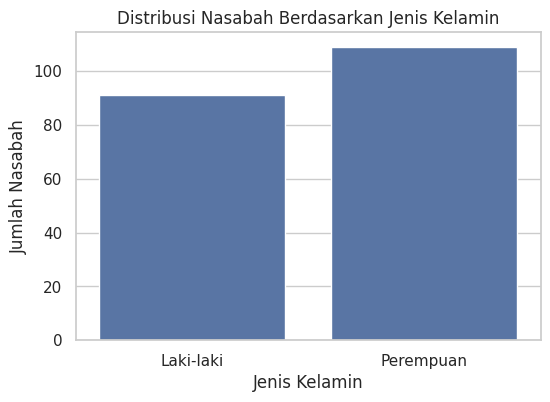

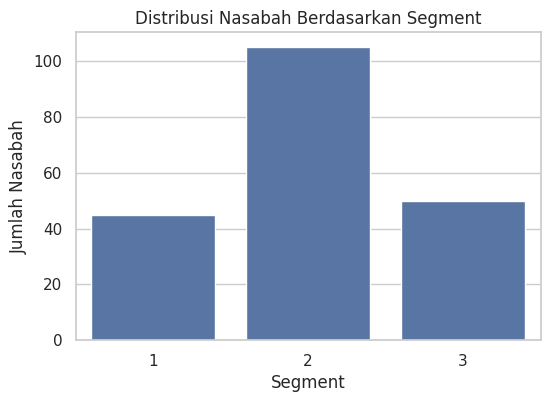

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex_label')
plt.title('Distribusi Nasabah Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah Nasabah')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='segment')
plt.title('Distribusi Nasabah Berdasarkan Segment')
plt.xlabel('Segment')
plt.ylabel('Jumlah Nasabah')
plt.show()


## EDA: Ringkasan Variabel Penggunaan Kartu Kredit

Variabel utama yang dianalisis:
- `pre_usage`: penggunaan kartu kredit sebelum campaign.
- `Post_usage_1month`: penggunaan kartu kredit 1 bulan setelah campaign.
- `post_usage_2ndmonth`: penggunaan kartu kredit 2 bulan setelah campaign.
- `Latest_mon_usage`: penggunaan kartu kredit 1 bulan terakhir.


In [12]:
usage_cols = ['pre_usage', 'Post_usage_1month', 'post_usage_2ndmonth', 'Latest_mon_usage']

usage_summary = df[usage_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
usage_summary['range'] = usage_summary['max'] - usage_summary['min']
display(usage_summary)


,count,mean,median,std,min,max,range
pre_usage,200.0000,52.2300,50.0000,10.2529,28.0000,76.0000,48.0000
Post_usage_1month,200.0000,52.7750,54.0000,9.4786,31.0000,67.0000,36.0000
post_usage_2ndmonth,200.0000,58.0525,59.4000,10.4264,34.1000,73.7000,39.6000
Latest_mon_usage,200.0000,63.1740,62.4000,11.2421,39.6000,90.0000,50.4000


## Histogram Variabel Penting

Histogram digunakan untuk melihat pola persebaran data. Variabel yang dipilih adalah variabel penggunaan kartu kredit karena variabel tersebut langsung berkaitan dengan keberhasilan campaign.


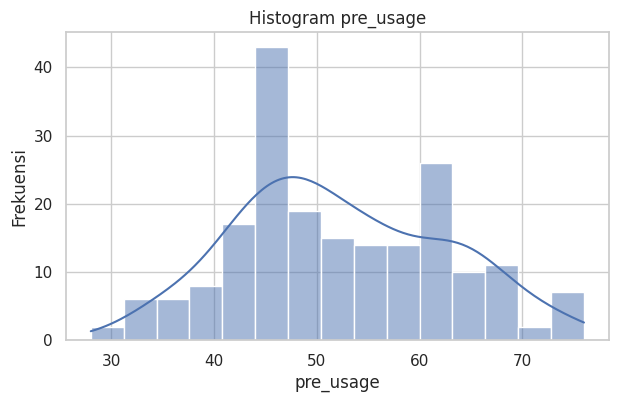

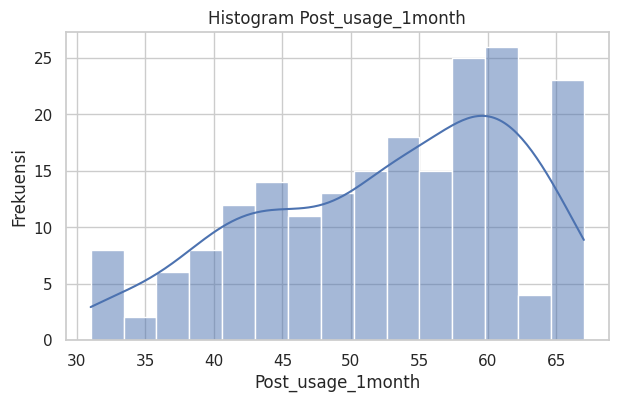

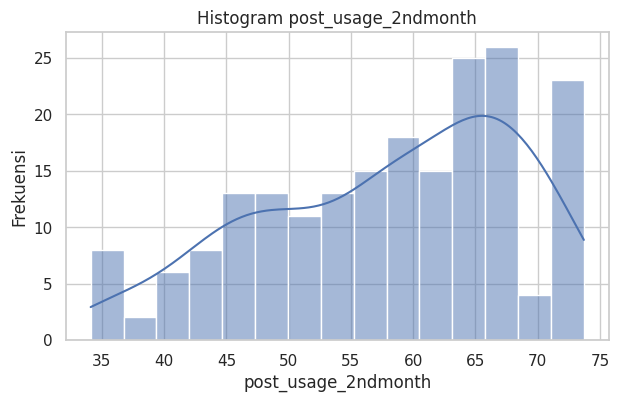

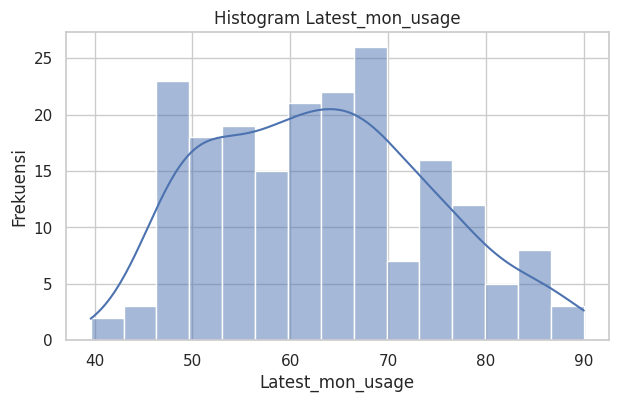

In [13]:
for col in usage_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=15, kde=True)
    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()


## 8. Boxplot Sebelum dan Setelah Campaign

Boxplot membantu melihat perubahan median, sebaran data, dan potensi outlier antarperiode.


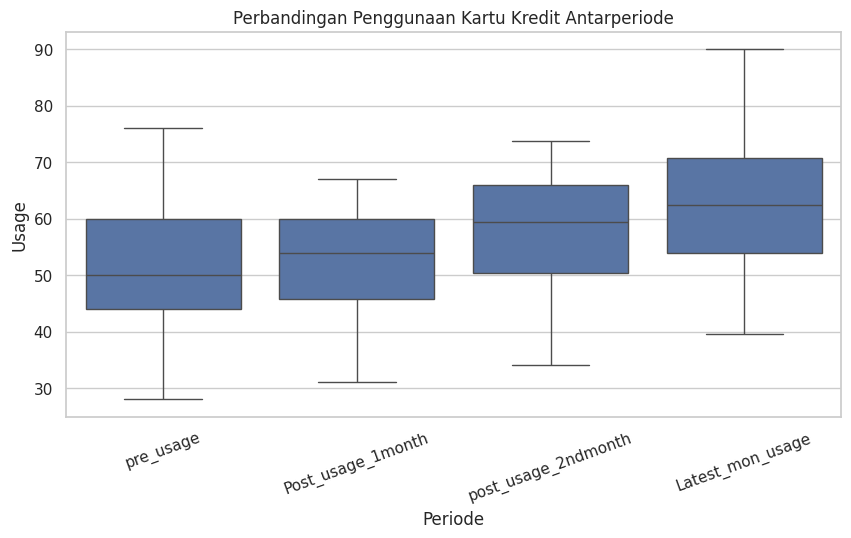

In [14]:
usage_long = df[usage_cols].melt(var_name='Periode', value_name='Usage')

plt.figure(figsize=(10,5))
sns.boxplot(data=usage_long, x='Periode', y='Usage')
plt.title('Perbandingan Penggunaan Kartu Kredit Antarperiode')
plt.xlabel('Periode')
plt.ylabel('Usage')
plt.xticks(rotation=20)
plt.show()


## Rata-rata Usage Sebelum dan Setelah Campaign

Grafik ini menunjukkan perubahan rata-rata penggunaan kartu kredit antarperiode.


,Periode,Rata-rata Usage
0,pre_usage,52.2300
1,Post_usage_1month,52.7750
2,post_usage_2ndmonth,58.0525
3,Latest_mon_usage,63.1740


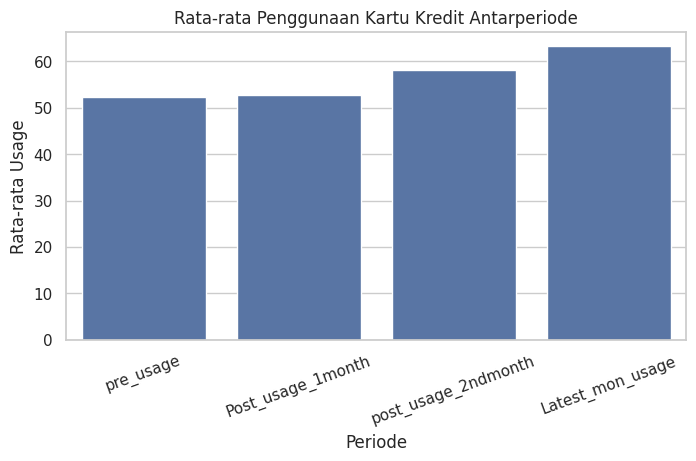

In [15]:
mean_usage = df[usage_cols].mean().reset_index()
mean_usage.columns = ['Periode', 'Rata-rata Usage']

display(mean_usage)

plt.figure(figsize=(8,4))
sns.barplot(data=mean_usage, x='Periode', y='Rata-rata Usage')
plt.title('Rata-rata Penggunaan Kartu Kredit Antarperiode')
plt.xlabel('Periode')
plt.ylabel('Rata-rata Usage')
plt.xticks(rotation=20)
plt.show()


# 2. Lakukan uji hipotesis untuk melihat apakah kampanye yang dilakukan berhasil. (Hint: gunakan fungsi ttest_rel):

a. Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 1 bulan setelah kampanye.

b. Bandingkan penggunaan kartu kredit antara sebelum kampanye dengan 2 bulan setelah kampanye.


## Uji Hipotesis No. 2: Apakah Campaign Berhasil?

Karena data sebelum dan sesudah campaign berasal dari nasabah yang sama, maka uji yang digunakan adalah **paired sample t-test** atau `ttest_rel`.

Definisi keberhasilan campaign dalam analisis ini adalah: penggunaan kartu kredit setelah campaign lebih tinggi secara signifikan dibandingkan sebelum campaign.

Karena arah keberhasilan sudah jelas, uji utama menggunakan **one-tailed test** dengan `alternative='greater'`.

### 1. Pre Usage vs Post Usage 1 Month

H0: Rata-rata penggunaan kartu kredit 1 bulan setelah campaign tidak lebih tinggi daripada sebelum campaign.  
H1: Rata-rata penggunaan kartu kredit 1 bulan setelah campaign lebih tinggi daripada sebelum campaign.

### 2. Pre Usage vs Post Usage 2nd Month

H0: Rata-rata penggunaan kartu kredit 2 bulan setelah campaign tidak lebih tinggi daripada sebelum campaign.  
H1: Rata-rata penggunaan kartu kredit 2 bulan setelah campaign lebih tinggi daripada sebelum campaign.


In [16]:
def paired_ttest_campaign(before_col, after_col, label):
    before = df[before_col]
    after = df[after_col]
    diff = after - before

    test = stats.ttest_rel(after, before, alternative='greater')
    test_two_sided = stats.ttest_rel(after, before)
    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=len(diff)-1,
        loc=diff.mean(),
        scale=stats.sem(diff)
    )
    cohen_dz = diff.mean() / diff.std(ddof=1)

    result = {
        'Kasus': label,
        'Mean Before': before.mean(),
        'Mean After': after.mean(),
        'Mean Difference': diff.mean(),
        't-statistic': test.statistic,
        'p-value one-tailed': test.pvalue,
        'p-value two-tailed': test_two_sided.pvalue,
        '95% CI Diff Lower': ci_low,
        '95% CI Diff Upper': ci_high,
        'Cohen dz': cohen_dz,
        'Keputusan': 'Tolak H0' if test.pvalue < alpha else 'Gagal Tolak H0',
        'Kesimpulan': 'Signifikan meningkat' if test.pvalue < alpha else 'Tidak signifikan meningkat'
    }
    return result

campaign_results = pd.DataFrame([
    paired_ttest_campaign('pre_usage', 'Post_usage_1month', 'Pre vs Post 1 Month'),
    paired_ttest_campaign('pre_usage', 'post_usage_2ndmonth', 'Pre vs Post 2nd Month')
])

display(campaign_results)


,Kasus,Mean Before,Mean After,Mean Difference,t-statistic,p-value one-tailed,p-value two-tailed,95% CI Diff Lower,95% CI Diff Upper,Cohen dz,Keputusan,Kesimpulan
0,Pre vs Post 1 Month,52.2300,52.7750,0.5450,0.8673,0.1934,0.3868,-0.6941,1.7841,0.0613,Gagal Tolak H0,Tidak signifikan meningkat
1,Pre vs Post 2nd Month,52.2300,58.0525,5.8225,8.8668,0.0000,0.0000,4.5276,7.1174,0.6270,Tolak H0,Signifikan meningkat


## 3. Lakukan uji hipotesis untuk melihat apakah ada perbedaan penggunaan kartu kredit antara kelompok laki-laki dan perempuan setelah kampanye. (Hint: gunakan fungsi ttest_ind):

a. Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 1 bulan setelah kampanye. [10 poin]

b. Bandingkan penggunaan kartu kredit kelompok laki-laki dengan perempuan 2 bulan setelah kampanye. [10 poin]

## Uji Hipotesis No. 3: Apakah Ada Perbedaan Usage antara Laki-laki dan Perempuan Setelah Campaign?

Karena kelompok laki-laki dan perempuan adalah dua kelompok berbeda, maka uji yang digunakan adalah **independent sample t-test** atau `ttest_ind`.

Karena pertanyaan meminta "ada perbedaan", maka uji menggunakan **two-tailed test**.

Sebelum menjalankan independent t-test, dilakukan uji Levene untuk melihat apakah varians kedua kelompok dapat dianggap sama.

Aturan:
- Jika p-value Levene > 0.05, gunakan `equal_var=True`.
- Jika p-value Levene <= 0.05, gunakan `equal_var=False` atau Welch t-test.

### 1. Laki-laki vs Perempuan 1 Bulan Setelah Campaign

H0: Tidak ada perbedaan rata-rata penggunaan kartu kredit antara laki-laki dan perempuan 1 bulan setelah campaign.  
H1: Ada perbedaan rata-rata penggunaan kartu kredit antara laki-laki dan perempuan 1 bulan setelah campaign.

### 2. Laki-laki vs Perempuan 2 Bulan Setelah Campaign

H0: Tidak ada perbedaan rata-rata penggunaan kartu kredit antara laki-laki dan perempuan 2 bulan setelah campaign.  
H1: Ada perbedaan rata-rata penggunaan kartu kredit antara laki-laki dan perempuan 2 bulan setelah campaign.


In [17]:
def independent_ttest_gender(col, label):
    male = df.loc[df['sex'] == 0, col]
    female = df.loc[df['sex'] == 1, col]

    levene = stats.levene(male, female)
    equal_var = True if levene.pvalue > alpha else False
    test = stats.ttest_ind(male, female, equal_var=equal_var)

    n_male, n_female = len(male), len(female)
    s_male, s_female = male.std(ddof=1), female.std(ddof=1)
    pooled_sd = np.sqrt(((n_male - 1) * s_male**2 + (n_female - 1) * s_female**2) / (n_male + n_female - 2))
    cohen_d = (male.mean() - female.mean()) / pooled_sd

    result = {
        'Kasus': label,
        'N Laki-laki': n_male,
        'N Perempuan': n_female,
        'Mean Laki-laki': male.mean(),
        'Mean Perempuan': female.mean(),
        'Mean Difference L-P': male.mean() - female.mean(),
        'Levene p-value': levene.pvalue,
        'equal_var used': equal_var,
        't-statistic': test.statistic,
        'p-value': test.pvalue,
        'Cohen d': cohen_d,
        'Keputusan': 'Tolak H0' if test.pvalue < alpha else 'Gagal Tolak H0',
        'Kesimpulan': 'Ada perbedaan signifikan' if test.pvalue < alpha else 'Tidak ada perbedaan signifikan'
    }
    return result

gender_results = pd.DataFrame([
    independent_ttest_gender('Post_usage_1month', 'Gender vs Post 1 Month'),
    independent_ttest_gender('post_usage_2ndmonth', 'Gender vs Post 2nd Month')
])

display(gender_results)


,Kasus,N Laki-laki,N Perempuan,Mean Laki-laki,Mean Perempuan,Mean Difference L-P,Levene p-value,equal_var used,t-statistic,p-value,Cohen d,Keputusan,Kesimpulan
0,Gender vs Post 1 Month,91,109,50.1209,54.9908,-4.8699,0.0022,False,-3.6564,0.0003,-0.5302,Tolak H0,Ada perbedaan signifikan
1,Gender vs Post 2nd Month,91,109,55.1330,60.4899,-5.3569,0.0022,False,-3.6564,0.0003,-0.5302,Tolak H0,Ada perbedaan signifikan


## Visualisasi Perbandingan Gender Setelah Campaign

Grafik berikut menunjukkan perbandingan rata-rata penggunaan kartu kredit laki-laki dan perempuan setelah campaign.


,sex_label,Post_usage_1month,post_usage_2ndmonth
0,Laki-laki,50.1209,55.1330
1,Perempuan,54.9908,60.4899


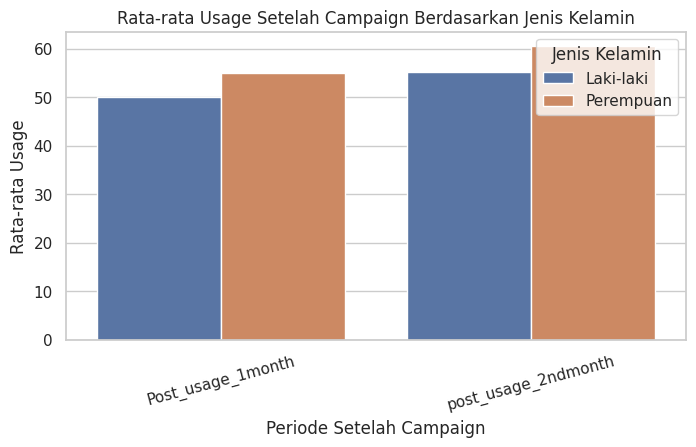

In [18]:
gender_mean = df.groupby('sex_label')[['Post_usage_1month', 'post_usage_2ndmonth']].mean().reset_index()
gender_mean_long = gender_mean.melt(id_vars='sex_label', var_name='Periode', value_name='Rata-rata Usage')

display(gender_mean)

plt.figure(figsize=(8,4))
sns.barplot(data=gender_mean_long, x='Periode', y='Rata-rata Usage', hue='sex_label')
plt.title('Rata-rata Usage Setelah Campaign Berdasarkan Jenis Kelamin')
plt.xlabel('Periode Setelah Campaign')
plt.ylabel('Rata-rata Usage')
plt.xticks(rotation=15)
plt.legend(title='Jenis Kelamin')
plt.show()


## Catatan Kritis Validasi Data

Bagian ini bersifat tambahan tetapi penting untuk menunjukkan ketelitian analisis.
Kode berikut mengecek apakah `post_usage_2ndmonth` benar-benar data observasi baru atau hanya hasil turunan dari `Post_usage_1month`.


In [19]:
check_relation = np.allclose(df['post_usage_2ndmonth'], df['Post_usage_1month'] * 1.1)
max_difference = np.abs(df['post_usage_2ndmonth'] - df['Post_usage_1month'] * 1.1).max()

print('Apakah post_usage_2ndmonth = Post_usage_1month * 1.1?', check_relation)
print('Selisih maksimum:', max_difference)


Apakah post_usage_2ndmonth = Post_usage_1month * 1.1? True
Selisih maksimum: 1.4210854715202004e-14


Jika hasilnya `True`, maka terdapat indikasi bahwa nilai penggunaan 2 bulan setelah campaign merupakan hasil perhitungan dari penggunaan 1 bulan setelah campaign. Artinya, interpretasi uji hipotesis bulan kedua perlu hati-hati karena variabel tersebut kemungkinan tidak sepenuhnya independen sebagai pengamatan baru.


## Kesimpulan Akhir

Berdasarkan hasil analisis:

1. Dataset terdiri dari 200 baris dan 10 kolom, tanpa missing value pada data yang dianalisis.
2. Rata-rata `pre_usage` adalah 52.23.
3. Rata-rata `Post_usage_1month` adalah 52.775. Kenaikannya hanya sekitar 0.545 poin.
4. Uji paired t-test satu arah untuk 1 bulan setelah campaign menghasilkan p-value lebih besar dari 0.05. Maka, tidak cukup bukti bahwa campaign berhasil meningkatkan penggunaan kartu kredit pada bulan pertama.
5. Rata-rata `post_usage_2ndmonth` adalah 58.0525. Kenaikannya sekitar 5.8225 poin dari sebelum campaign.
6. Uji paired t-test satu arah untuk 2 bulan setelah campaign menghasilkan p-value lebih kecil dari 0.05. Maka, terdapat bukti statistik bahwa penggunaan kartu kredit meningkat signifikan pada bulan kedua.
7. Uji independent t-test menunjukkan terdapat perbedaan signifikan antara laki-laki dan perempuan pada 1 bulan dan 2 bulan setelah campaign.
8. Rata-rata penggunaan perempuan lebih tinggi daripada laki-laki pada kedua periode setelah campaign.
9. Catatan kritis: `post_usage_2ndmonth` terindikasi sebagai 1.1 kali `Post_usage_1month`, sehingga validitas data bulan kedua perlu diverifikasi sebelum digunakan untuk keputusan bisnis yang kuat.
